In [86]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Diccionario de Datos: Dataset de Anemia (HISMINSA)

Este conjunto de datos contiene los registros de detección de anemia en niños menores de 5 años, integrando variables clínicas, demográficas y geográficas.

| Variable | Descripción | Tipo | Tamaño | Notas Adicionales |
| :--- | :--- | :--- | :--- | :--- |
| **PK_REGISTRO** | Código identificador único del registro | Numérico | 10 | Clave primaria. |
| **FECHA_REGISTRO** | Fecha de registro en el sistema | Texto | 8 | Formato: `aaaammdd`. |
| **GENERO** | Sexo del paciente | Texto | 1 | M = Masculino, F = Femenino. |
| **EDAD_REGISTRO** | Valor numérico de la edad | Numérico | 4 | Edad al ser atendido. |
| **TIPO_EDAD** | Unidad de medida de la edad | Texto | 1 | A=Años, M=Meses, D=Días. |
| **ETNIA** | Grupo étnico del paciente | Texto | 20 | Autoidentificación. |
| **F_ATENCION** | Fecha de la prestación de salud | Texto | 8 | Formato: `aaaammdd`. |
| **GRADO_SEVERIDAD** | Nivel de anemia detectado (**Target**) | Texto | 5 | LEV, MOD, SEV. |
| **DIAGNOSTICO** | Descripción del diagnóstico médico | Texto | 900 | Detalle clínico. |
| **TIPO_DIAGNOSTICO** | Categoría de la evaluación | Texto | 1 | D=Definitivo, P=Presuntivo, R=Repetitivo. |
| **DESCRIPCION_FINANCIADOR** | Entidad que cubre el gasto (Seguro) | Texto | 200 | Ej: SIS, EsSalud. |
| **CANTIDAD** | Total de diagnósticos realizados | Numérico | 4 | Conteo por registro. |
| **PROVINCIA** | Provincia de residencia del paciente | Texto | 510 | Geografía política. |
| **DEPARTAMENTO** | Departamento de residencia del paciente | Texto | 510 | Geografía política. |
| **DISTRITO** | Distrito de residencia del paciente | Texto | 510 | Geografía política. |
| **RED** | Red de salud encargada | Texto | 510 | Administración MINSA. |
| **MICRORED** | Microred de salud específica | Texto | 510 | Administración MINSA. |
| **NOMBRE_ESTABLECIMIENTO** | Nombre de la IPRESS de atención | Texto | 200 | Local de salud. |
| **CODIGO_UNICO** | Código de identificación de red | Numérico | 10 | ID administrativo. |
| **LONGITUD** | Coordenada geográfica (Longitud) | Decimal | 50 | Punto X del establecimiento. |
| **LATITUD** | Coordenada geográfica (Latitud) | Decimal | 50 | Punto Y del establecimiento. |
| **FECHA_CORTE** | Fecha de exportación de los datos | Numérico | 8 | Última actualización. |

---

In [91]:
df = pd.read_csv("ANEMIA_DA.csv", sep = ";")
df['GRADO_SEVERIDAD'] = df['GRADO_SEVERIDAD'].str.upper()
df['ETNIA_AGRUPADA'] = df['ETNIA'].mask(df['ETNIA'].str.upper() != 'MESTIZO', 'INDIGENA')
altitud_media = {
    'PROVINCIA': [
        'MOYOBAMBA', 'BELLAVISTA', 'EL DORADO', 'HUALLAGA', 
        'LAMAS', 'MARISCAL CACERES', 'PICOTA', 'RIOJA', 
        'SAN MARTIN', 'TOCACHE'
    ],
    'ALTITUD_MSNM': [878, 285, 346, 303, 791, 282, 223, 841, 356, 502]
}
df_maestro_alt = pd.DataFrame(altitud_media)
df['PROVINCIA'] = df['PROVINCIA'].str.upper().str.strip()
df['PROVINCIA'] = df['PROVINCIA'].str.replace('Á', 'A').str.replace('É', 'E').str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U')
df = df.merge(df_maestro_alt, on='PROVINCIA', how='left')

def dias(row):
    edad = row['EDAD_REGISTRO']
    tipo = str(row['TIPO_EDAD']).upper().strip()
    
    if tipo == 'A':    # Años
        return edad
    elif tipo == 'M':  # Meses
        return edad * 30
    elif tipo == 'D':  # Días
        return edad
    else:
        return None    

df['EDAD_EN_DIAS'] = df.apply(dias, axis=1)

   EDAD_REGISTRO TIPO_EDAD  EDAD_EN_DIAS
0              5         A          1825
1              3         A          1095
2              5         A          1825
3              4         A          1460
4              5         A          1825


In [103]:
df.groupby(['GRADO_SEVERIDAD', 'DIAGNOSTICO'])['PK_REGISTRO'].count().unstack()

DIAGNOSTICO,ANEMIA DE TIPO NO ESPECIFICADO,ANEMIA POR DEFICIENCIA DE HIERRO SECUNDARIA A PERDIDA DE SANGRE (CRONICA),ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFICACION,OTRAS ANEMIAS POR DEFICIENCIA DE HIERRO
GRADO_SEVERIDAD,,,,
LEV,25.0,73.0,46304.0,54.0
MOD,3.0,15.0,12497.0,8.0
SEV,NaN,15.0,231.0,NaN


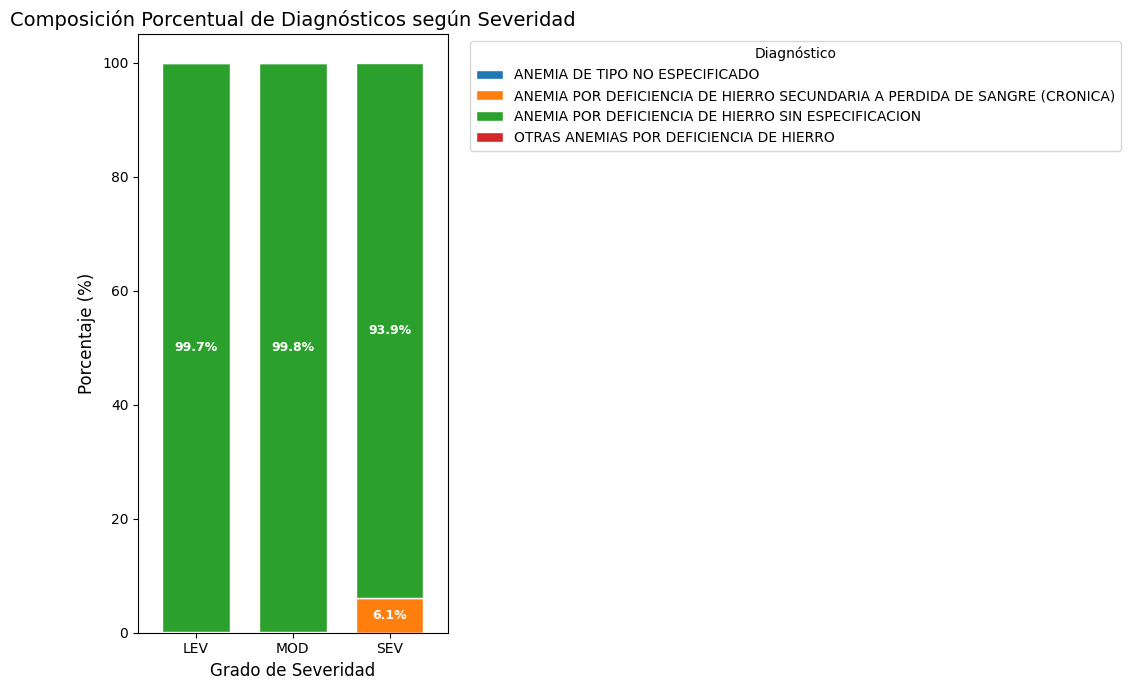

In [101]:
# 1. Agrupamos y pivotamos los datos
plot_data = df.groupby(['GRADO_SEVERIDAD', 'DIAGNOSTICO'])['PK_REGISTRO'].count().unstack()

# 2. Convertimos a porcentajes (cada fila sumará 100%)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# 3. Graficamos
ax = plot_data_pct.plot(kind='bar', 
                        stacked=True, 
                        figsize=(11, 7), 
                        width=0.7,
                        edgecolor='white')

# 4. Agregamos las etiquetas de porcentaje dentro de las barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Solo dibujamos el texto si el segmento es visible (>5%)
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center',
                fontsize=9,
                color='white',
                weight='bold')

# 5. Estética final
plt.title('Composición Porcentual de Diagnósticos según Severidad', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Grado de Severidad', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Diagnóstico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

In [56]:
df.head()

,PK_REGISTRO,FECHA_REGISTRO,GENERO,EDAD_REGISTRO,TIPO_EDAD,ETNIA,F_ATENCION,GRADO_SEVERIDAD,DIAGNOSTICO,TIPO_DIAGNOSTICO,...,DEPARTAMENTO,DISTRITO,RED,MICRORED,NOMBRE_ESTABLECIMIENTO,CODIGO_UNICO,LONGITUD,LATITUD,FECHA_CORTE,ETNIA_AGRUPADA
0,1,20180810,M,5,A,Mestizo,20180810,MOD,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,HUICUNGO,MARISCAL CACERES,HUICUNGO,PIZARRO,6571,-76.985172,-7.250180,20250424,Mestizo
1,2,20170406,M,3,A,Mestizo,20170406,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,TARAPOTO,SAN MARTIN,TARAPOTO,HUAYCO TARAPOTO,6371,-76.367503,-6.502062,20250424,Mestizo
2,3,20180719,F,5,A,Mestizo,20180719,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,SAN JOSE DE SISA,EL DORADO,SAN JOSE DE SISA,HOSPITAL RURAL SAN JOSE DE SISA,6485,-76.688596,-6.614755,20250424,Mestizo
3,4,20170912,M,4,A,Mestizo,20170912,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,RIOJA,RIOJA,NUEVO RIOJA,LA PERLA DE CASCAYUNGA,6708,-77.236470,-6.092303,20250424,Mestizo
4,5,20180718,F,5,A,Mestizo,20180718,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,SAN JOSE DE SISA,EL DORADO,SAN JOSE DE SISA,HOSPITAL RURAL SAN JOSE DE SISA,6485,-76.688596,-6.614755,20250424,Mestizo


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59225 entries, 0 to 59224
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PK_REGISTRO              59225 non-null  int64  
 1   FECHA_REGISTRO           59225 non-null  int64  
 2   GENERO                   59225 non-null  object 
 3   EDAD_REGISTRO            59225 non-null  int64  
 4   TIPO_EDAD                59225 non-null  object 
 5   ETNIA                    59225 non-null  object 
 6   F_ATENCION               59225 non-null  int64  
 7   GRADO_SEVERIDAD          59225 non-null  object 
 8   DIAGNOSTICO              59225 non-null  object 
 9   TIPO_DIAGNOSTICO         59225 non-null  object 
 10  DESCRIPCION_FINANCIADOR  59225 non-null  object 
 11  CANTIDAD                 59225 non-null  int64  
 12  PROVINCIA                59225 non-null  object 
 13  DEPARTAMENTO             59225 non-null  object 
 14  DISTRITO              

In [79]:
df.describe()

,PK_REGISTRO,FECHA_REGISTRO,EDAD_REGISTRO,F_ATENCION,CANTIDAD,CODIGO_UNICO,LONGITUD,LATITUD,FECHA_CORTE,ALTITUD_MSNM
count,59225.000000,5.922500e+04,59225.000000,5.922500e+04,59225.000000,59225.000000,59225.000000,59225.000000,59225.0,59225.000000
mean,29613.000000,2.020370e+07,3.481857,2.020370e+07,1.007092,6504.450536,-76.616940,-6.604169,20250424.0,531.268789
std,17096.929183,2.256667e+04,2.664805,2.256667e+04,0.084913,978.482362,0.386289,0.623823,0.0,242.306524
min,1.000000,2.016010e+07,-2.000000,2.016010e+07,1.000000,6270.000000,-77.634017,-8.753550,20250424.0,223.000000
25%,14807.000000,2.018120e+07,1.000000,2.018120e+07,1.000000,6352.000000,-76.850305,-6.792527,20250424.0,356.000000
50%,29613.000000,2.020083e+07,3.000000,2.020083e+07,1.000000,6406.000000,-76.577641,-6.485973,20250424.0,356.000000
75%,44419.000000,2.022091e+07,6.000000,2.022091e+07,1.000000,6494.000000,-76.355165,-6.154090,20250424.0,791.000000
max,59225.000000,2.025043e+07,80.000000,2.025043e+07,3.000000,31276.000000,-75.593100,-5.639154,20250424.0,878.000000


<Axes: xlabel='GRADO_SEVERIDAD'>

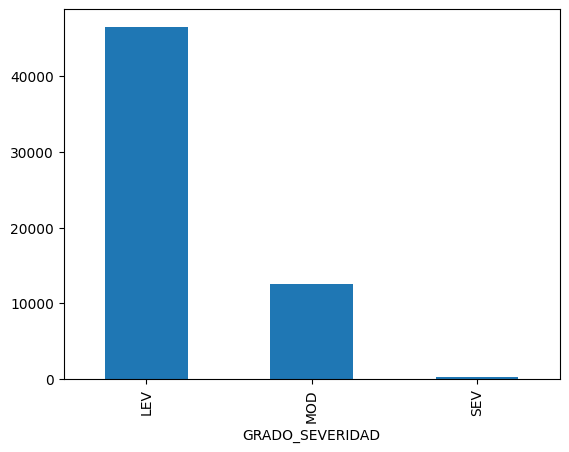

In [58]:
(df['GRADO_SEVERIDAD'].value_counts()).plot(kind='bar')

<Axes: xlabel='ETNIA_AGRUPADA'>

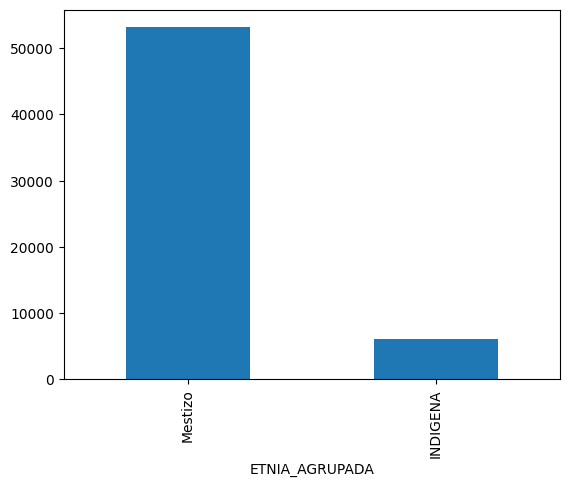

In [82]:
(df['ETNIA_AGRUPADA'].value_counts()).plot(kind='bar')

<Axes: xlabel='GENERO'>

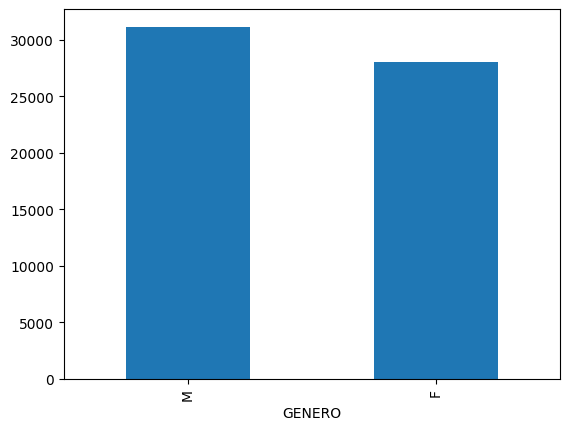

In [83]:
(df['GENERO'].value_counts()).plot(kind='bar')

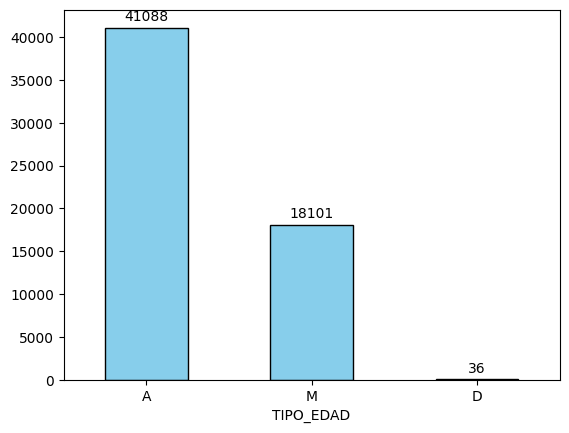

In [90]:
# 1. Creamos el gráfico y guardamos el objeto 'ax' (los ejes)
ax = (df['TIPO_EDAD'].value_counts()).plot(kind='bar', color='skyblue', edgecolor='black')

# 2. Agregamos las etiquetas sobre las barras
# ax.containers contiene la información de las barras generadas
ax.bar_label(ax.containers[0], padding=3)

plt.xticks(rotation=0) # Mantiene los números del eje X horizontales
plt.show()

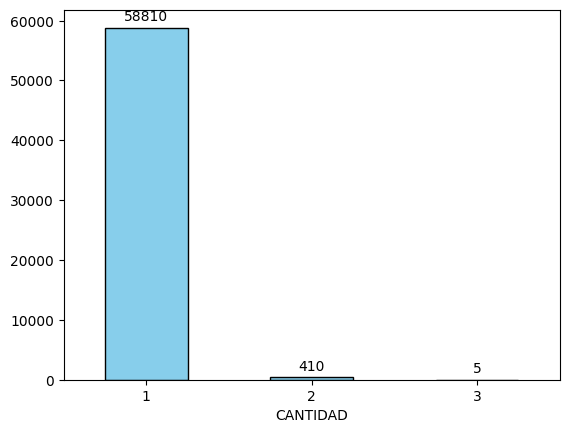

In [89]:
# 1. Creamos el gráfico y guardamos el objeto 'ax' (los ejes)
ax = (df['CANTIDAD'].value_counts()).plot(kind='bar', color='skyblue', edgecolor='black')

# 2. Agregamos las etiquetas sobre las barras
# ax.containers contiene la información de las barras generadas
ax.bar_label(ax.containers[0], padding=3)

plt.xticks(rotation=0) # Mantiene los números del eje X horizontales
plt.show()

In [81]:
(df['ETNIA_AGRUPADA'].value_counts())

ETNIA_AGRUPADA
Mestizo     53183
INDIGENA     6042
Name: count, dtype: int64